In [ ]:
import json
import os

DATA_DIR = '../data'

def load_jsonl(filename):
    path = os.path.join(DATA_DIR, filename)
    with open(path,'r', encoding='utf-8') as f:
        return [json.loads(line) for line in f]

train_data = load_jsonl('train_dataset.jsonl')
test_data = load_jsonl('test_dataset.jsonl')

labelset = []
labelset_path = os.path.join(DATA_DIR, 'labelset.txt')

with open(labelset_path, 'r') as file:
    for line in file:
        labelset.append(line.strip())

with open(os.path.join(DATA_DIR, "labelset_descriptions.json"), "r", encoding="utf-8") as f:
    descriptions = json.load(f)

In [ ]:
from collections import Counter
import numpy as np
import pandas as pd

def dataset_stats(data):
    num_docs = len(data)
    ann_counts = []
    code_counter = Counter()

    for doc in data:
        annotations = doc.get("annotations", [])
        ann_counts.append(len(annotations))
        for ann in annotations:
            code = ann.get("code", "UNKNOWN")
            code_counter[code] += 1

    total_anns = sum(ann_counts)
    mean_anns = np.mean(ann_counts)
    min_anns = np.min(ann_counts)
    max_anns = np.max(ann_counts)
    unique_codes = len(code_counter)
    top_10_codes = code_counter.most_common(10)

    return {
        "num_docs": num_docs,
        "total_annotations": total_anns,
        "mean_annotations": round(mean_anns, 2),
        "min_annotations": min_anns,
        "max_annotations": max_anns,
        "unique_codes": unique_codes,
        "top_10_codes": top_10_codes,
        "code_counts": dict(code_counter),
    }

train_stats = dataset_stats(train_data)
test_stats = dataset_stats(test_data)

def print_stats(name, stats):
    print(f"=== {name.upper()} SET ===")
    print(f"Documents: {stats['num_docs']}")
    print(f"Total annotations: {stats['total_annotations']}")
    print(f"Annotations per doc - Mean: {stats['mean_annotations']}, Min: {stats['min_annotations']}, Max: {stats['max_annotations']}")
    print(f"Unique codes: {stats['unique_codes']}")
    print("Top 10 codes:")
    for code, count in stats['top_10_codes']:
        print(f"  {code}: {count}")
    print()

print_stats("train", train_stats)
print_stats("test", test_stats)


=== TRAIN SET ===
Documents: 1000
Total annotations: 10168
Annotations per doc - Mean: 10.17, Min: 1, Max: 33
Unique codes: 144
Top 10 codes:
  Z95: 1214
  I48: 835
  I25: 658
  R07: 529
  I21: 526
  I10: 525
  I50: 437
  R06: 421
  Y84: 412
  E11: 328

=== TEST SET ===
Documents: 500
Total annotations: 5696
Annotations per doc - Mean: 11.39, Min: 2, Max: 44
Unique codes: 106
Top 10 codes:
  Z95: 666
  I48: 412
  I25: 397
  Y84: 289
  I10: 269
  R07: 268
  R06: 263
  I21: 255
  I50: 249
  I34: 187



In [ ]:
import matplotlib.pyplot as plt

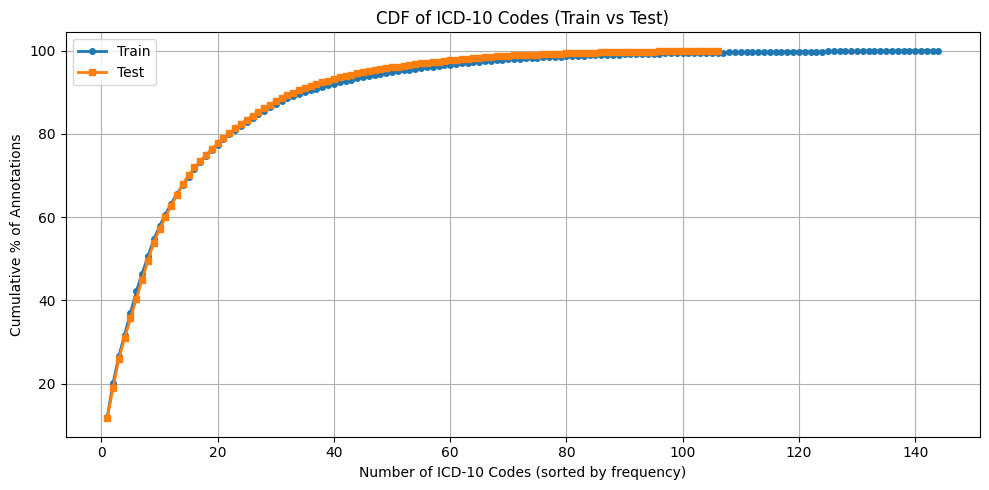

In [38]:
def plot_combined_code_cdf(train_counts, test_counts, title="CDF of ICD-10 Codes (Train vs Test)", filename=None):
    def get_cdf_data(counts):
        sorted_counts = sorted(counts.values(), reverse=True)
        cumulative = np.cumsum(sorted_counts)
        cumulative_percent = cumulative / cumulative[-1] * 100
        return list(range(1, len(sorted_counts) + 1)), cumulative_percent

    x_train, y_train = get_cdf_data(train_counts)
    x_test, y_test = get_cdf_data(test_counts)

    plt.figure(figsize=(10, 5))
    plt.plot(x_train, y_train, label='Train', linewidth=2, marker='o', markersize=4)
    plt.plot(x_test, y_test, label='Test', linewidth=2, marker='s', markersize=4)
    plt.xlabel("Number of ICD-10 Codes (sorted by frequency)")
    plt.ylabel("Cumulative % of Annotations")
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()

    if filename:
        plt.savefig(filename, dpi=300)
        plt.close()
    else:
        plt.show()
plot_combined_code_cdf(train_stats["code_counts"], test_stats["code_counts"])

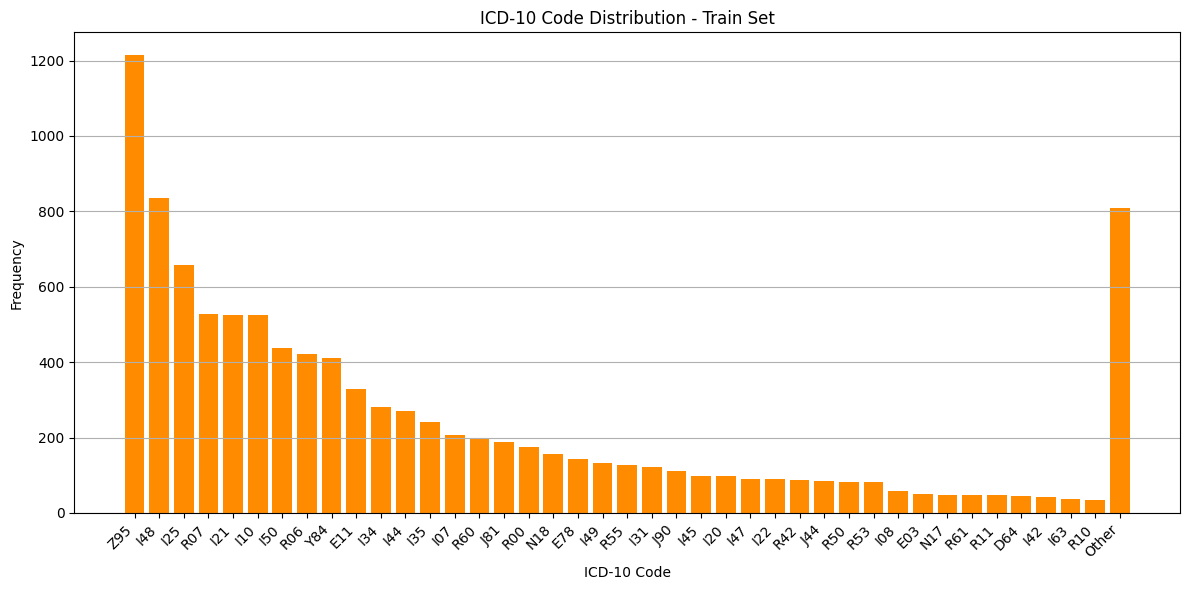

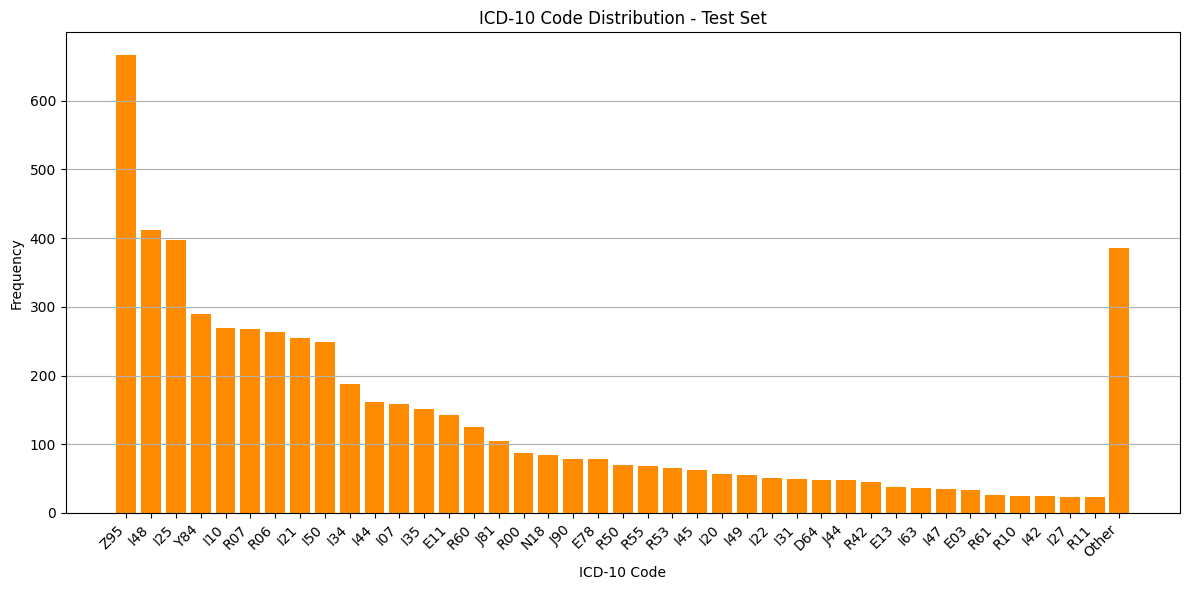

In [26]:
import matplotlib.pyplot as plt

def plot_top_codes_with_other(code_counts, top_n=30, title="ICD-10 Code Distribution"):
    sorted_items = sorted(code_counts.items(), key=lambda x: x[1], reverse=True)
    top_items = sorted_items[:top_n]
    other_items = sorted_items[top_n:]

    codes, freqs = zip(*top_items)
    other_freq = sum(freq for _, freq in other_items)

    codes = list(codes) + ["Other"]
    freqs = list(freqs) + [other_freq]

    plt.figure(figsize=(12, 6))
    plt.bar(codes, freqs, color='darkorange')
    plt.xlabel('ICD-10 Code')
    plt.ylabel('Frequency')
    plt.title(title)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.grid(axis='y')
    plt.show()

plot_top_codes_with_other(train_stats["code_counts"], top_n=40, title="ICD-10 Code Distribution - Train Set")
plot_top_codes_with_other(test_stats["code_counts"], top_n=40, title="ICD-10 Code Distribution - Test Set")


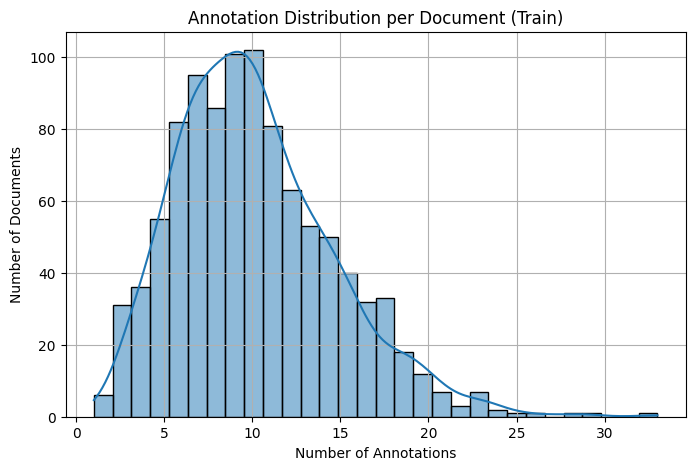

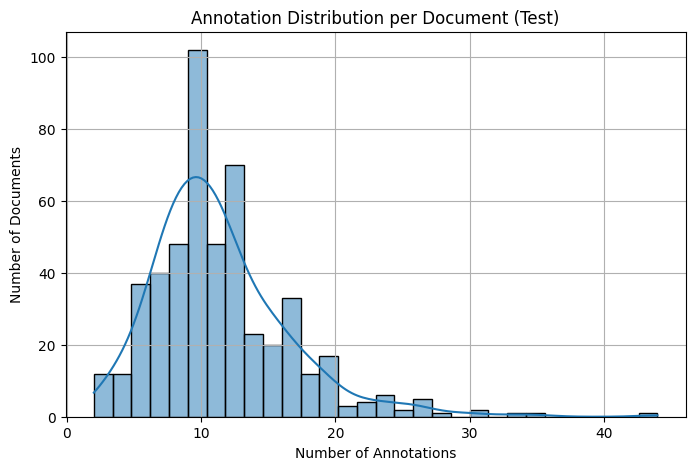

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_annotation_distribution(data, set_name):
    ann_counts = [len(doc["annotations"]) for doc in data]
    plt.figure(figsize=(8, 5))
    sns.histplot(ann_counts, bins=30, kde=True)
    plt.title(f'Annotation Distribution per Document ({set_name})')
    plt.xlabel('Number of Annotations')
    plt.ylabel('Number of Documents')
    plt.grid(True)
    plt.show()

plot_annotation_distribution(train_data, "Train")
plot_annotation_distribution(test_data, "Test")

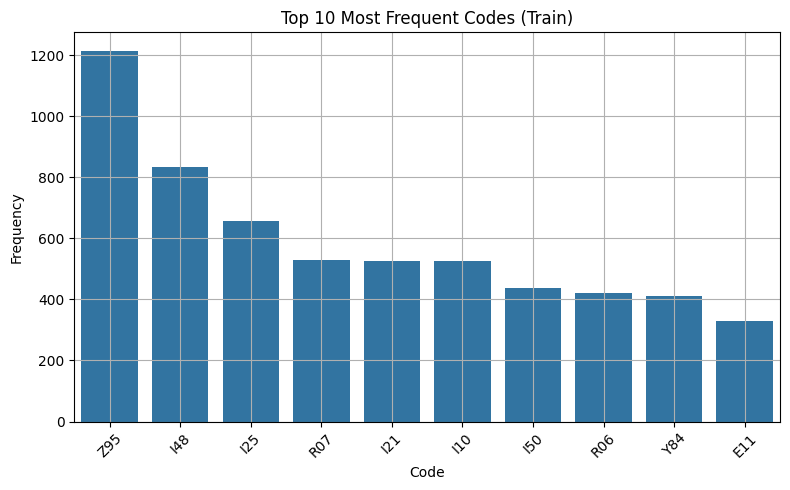

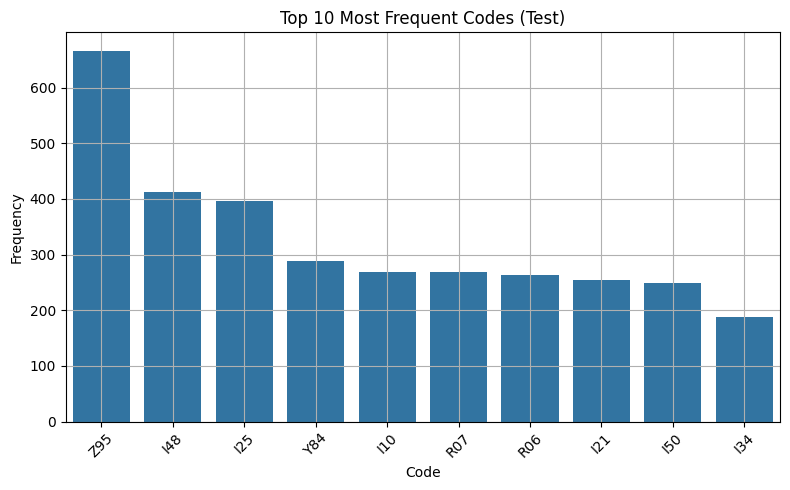

In [28]:
def plot_top_codes(stats, set_name):
    top_codes = stats["top_10_codes"]
    codes, counts = zip(*top_codes)

    plt.figure(figsize=(8, 5))
    sns.barplot(x=list(codes), y=list(counts))
    plt.title(f'Top 10 Most Frequent Codes ({set_name})')
    plt.xlabel('Code')
    plt.ylabel('Frequency')
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_top_codes(train_stats, "Train")
plot_top_codes(test_stats, "Test")

In [29]:
def print_top_codes_and_total(stats, set_name):
    top_codes = stats["top_10_codes"]
    total = 0
    print(f"Top 10 Most Frequent Codes in {set_name}:")
    for code, count in top_codes:
        print(f"  {code}: {count}")
        total += count
    print(f"Total annotations for top 10 codes in {set_name}: {total}\n")

print_top_codes_and_total(train_stats, "Train")
print_top_codes_and_total(test_stats, "Test")

Top 10 Most Frequent Codes in Train:
  Z95: 1214
  I48: 835
  I25: 658
  R07: 529
  I21: 526
  I10: 525
  I50: 437
  R06: 421
  Y84: 412
  E11: 328
Total annotations for top 10 codes in Train: 5885

Top 10 Most Frequent Codes in Test:
  Z95: 666
  I48: 412
  I25: 397
  Y84: 289
  I10: 269
  R07: 268
  R06: 263
  I21: 255
  I50: 249
  I34: 187
Total annotations for top 10 codes in Test: 3255



In [44]:
train_top = dict(train_stats["top_10_codes"])
test_top = dict(test_stats["top_10_codes"])

all_top_codes = set(train_top.keys()).union(test_top.keys())
num_codes = len(train_top)
print(f"COMPARISON TOP {num_codes} FREQUENT CODES\n")
print("Code\tTrain Count\tTest Count")
for code in sorted(all_top_codes):
    train_count = train_top.get(code, 0)
    test_count = test_top.get(code, 0)
    print(f"{code}\t{train_count}\t\t{test_count}")

COMPARISON TOP 10 FREQUENT CODES

Code	Train Count	Test Count
E11	328		0
I10	525		269
I21	526		255
I25	658		397
I34	0		187
I48	835		412
I50	437		249
R06	421		263
R07	529		268
Y84	412		289
Z95	1214		666


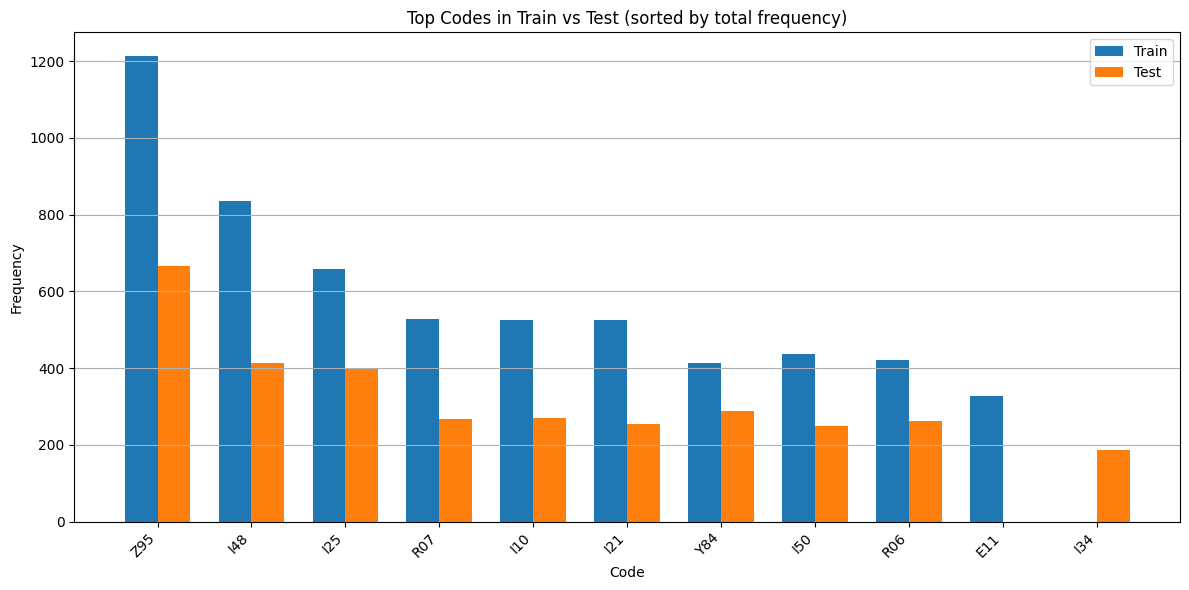

In [31]:
import matplotlib.pyplot as plt

def compare_top_codes(train_stats, test_stats):
    all_top_codes = set([code for code, _ in train_stats["top_10_codes"]] +
                        [code for code, _ in test_stats["top_10_codes"]])

    train_freqs = {code: 0 for code in all_top_codes}
    test_freqs = {code: 0 for code in all_top_codes}

    for code, count in train_stats["top_10_codes"]:
        train_freqs[code] = count
    for code, count in test_stats["top_10_codes"]:
        test_freqs[code] = count

    total_freqs = {code: train_freqs[code] + test_freqs[code] for code in all_top_codes}
    sorted_codes = sorted(total_freqs, key=total_freqs.get, reverse=True)

    x = range(len(sorted_codes))
    width = 0.35

    plt.figure(figsize=(12, 6))
    plt.bar(x, [train_freqs[c] for c in sorted_codes], width=width, label='Train')
    plt.bar([i + width for i in x], [test_freqs[c] for c in sorted_codes], width=width, label='Test')
    plt.xticks([i + width / 2 for i in x], sorted_codes, rotation=45, ha='right')
    plt.xlabel('Code')
    plt.ylabel('Frequency')
    plt.title('Top Codes in Train vs Test (sorted by total frequency)')
    plt.legend()
    plt.tight_layout()
    plt.grid(axis='y')
    plt.show()

compare_top_codes(train_stats, test_stats)


In [32]:
def get_code_set(data):
    codes = set()
    for doc in data:
        for ann in doc["annotations"]:
            codes.add(ann["code"])
    return codes

train_codes = get_code_set(train_data)
test_codes = get_code_set(test_data)

shared_codes = train_codes & test_codes
train_only = train_codes - test_codes
test_only = test_codes - train_codes

print(f"Total unique codes in train: {len(train_codes)}")
print(f"Total unique codes in test: {len(test_codes)}")
print(f"Shared codes: {len(shared_codes)}")
print(f"Train-only codes: {len(train_only)}")
print(f"Test-only codes: {len(test_only)}")

Total unique codes in train: 144
Total unique codes in test: 106
Shared codes: 95
Train-only codes: 49
Test-only codes: 11


In [33]:
def avg_annotation_length(data):
    lengths = []
    for doc in data:
        for ann in doc["annotations"]:
            mention = ann.get("mention", "")
            lengths.append(len(mention))
    return np.mean(lengths)

print("Avg annotation length (chars):")
print(f"Train: {avg_annotation_length(train_data):.2f}")
print(f"Test: {avg_annotation_length(test_data):.2f}")

Avg annotation length (chars):
Train: 14.31
Test: 13.48


In [34]:
def unique_mentions(data):
    mentions = set()
    for doc in data:
        for ann in doc["annotations"]:
            mentions.add(ann.get("mention", "").lower())

    return len(mentions)

print("Unique mentions:")
print(f"Train: {unique_mentions(train_data)}")
print(f"Test: {unique_mentions(test_data)}")

Unique mentions:
Train: 2418
Test: 1320


In [35]:
def annotation_density(data):
    total_ann_chars = 0
    total_text_chars = 0
    for doc in data:
        text = doc.get("text", "")
        total_text_chars += len(text)
        for ann in doc["annotations"]:
            total_ann_chars += len(ann.get("mention", ""))
    return total_ann_chars / total_text_chars if total_text_chars > 0 else 0

print("Annotation density:")
print(f"Train: {annotation_density(train_data):.4f}")
print(f"Test: {annotation_density(test_data):.4f}")

Annotation density:
Train: 0.0700
Test: 0.0743


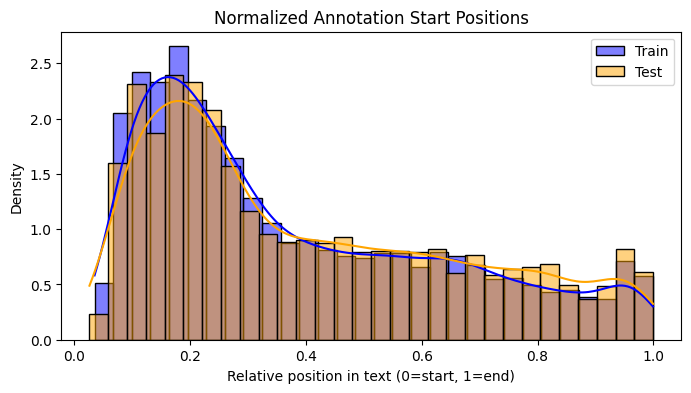

In [ ]:
def annotation_positions(data):
    positions = []
    for doc in data:
        text_len = len(doc.get("text", ""))
        for ann in doc["annotations"]:
            start = ann.get("start", 0)
            if text_len > 0:
                positions.append(start / text_len)
    return positions

positions_train = annotation_positions(train_data)
positions_test = annotation_positions(test_data)

plt.figure(figsize=(8, 4))
sns.histplot(positions_train, bins=30, kde=True, color='blue', label='Train', stat='density')
sns.histplot(positions_test, bins=30, kde=True, color='orange', label='Test', stat='density')
plt.title("Normalized Annotation Start Positions")
plt.xlabel("Relative position in text (0=start, 1=end)")
plt.legend()
plt.show()

In [45]:
top_codes = set(train_top.keys()) | set(test_top.keys())
rows = []
for code in top_codes:
    descs = descriptions.get(code, [])
    if not isinstance(descs, list):
        all_descriptions = descs
    for desc in descs:
        all_descriptions = " | ".join([str(d) for d in descs if d])
    rows.append({
        "Code": code, 
        "Train": train_top.get(code, 0),
        "Test": test_top.get(code, 0),
        "Descriptions": all_descriptions
    })
    

df = pd.DataFrame(rows)
print(df)

   Code  Train  Test                                       Descriptions
0   I48    835   412                  Κολπική μαρμαρυγή και πτερυγισμός
1   I10    525   269                    Ιδιοπαθής (πρωτοπαθής) υπέρταση
2   Z95   1214   666  Παρουσία καρδιακών και αγγειακών εμφυτευμάτων ...
3   I25    658   397  Χρόνια ισχαιμική καρδιοπάθεια | Αθηροσκληρωτικ...
4   Y84    412   289  Άλλες ιατρικές επεμβάσεις που προκαλούν παθολο...
5   E11    328     0        Μη ινσουλινοεξαρτώμενος σακχαρώδης διαβήτης
6   I34      0   187  Μη ρευματικές διαταραχές της μιτροειδούς βαλβί...
7   I21    526   255  Οξύ έμφραγμα του μυοκαρδίου | Οξύ διατοιχωματι...
8   R07    529   268  Πόνος στο λαιμό και το στήθος (θώρακα) | Πόνος...
9   R06    421   263  Διαταραχές της αναπνοής | Δύσπνοια | Συριγμός ...
10  I50    437   249  Καρδιακή ανεπάρκεια | Συμφορητική καρδιακή ανε...
